## Dropout in NN

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [27]:
np.random.seed(42)
tf.random.set_seed(42)

In [28]:
X, y = make_moons(
    n_samples=2000,
    noise=0.25,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 2)
y shape: (2000,)


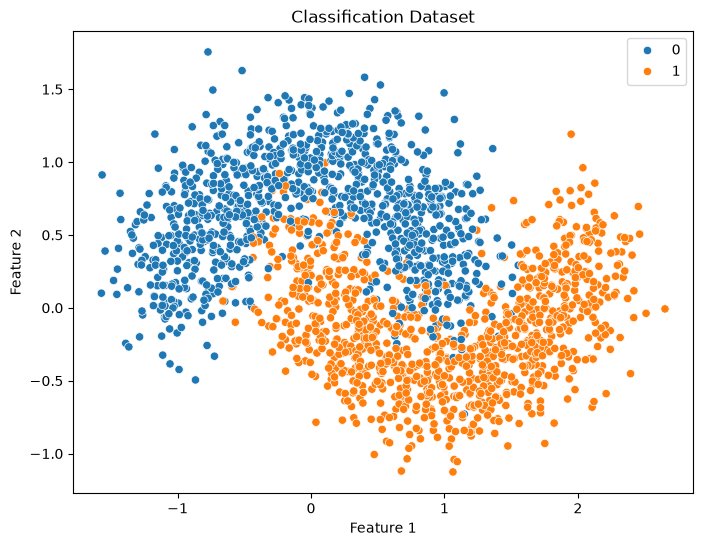

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y
)

plt.title("Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1600, 2)
Testing : (400, 2)


In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Without Dropout

In [32]:
model_no_dropout = Sequential([
    Dense(128, activation="relu", input_shape=(2,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

c:\Users\alili\100_days_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model_no_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
history_no_dropout = model_no_dropout.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [35]:
loss_no_dropout, accuracy_no_dropout = model_no_dropout.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss_no_dropout)
print("Test Accuracy:", accuracy_no_dropout)

Test Loss: 0.2209755778312683
Test Accuracy: 0.9225000143051147


### With Dropout

In [36]:
model_dropout = Sequential([
    Dense(128, activation="relu", input_shape=(2,)),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [37]:
model_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [39]:
loss_dropout, accuracy_dropout = model_dropout.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss_dropout)
print("Test Accuracy:", accuracy_dropout)

Test Loss: 0.1855393648147583
Test Accuracy: 0.925000011920929


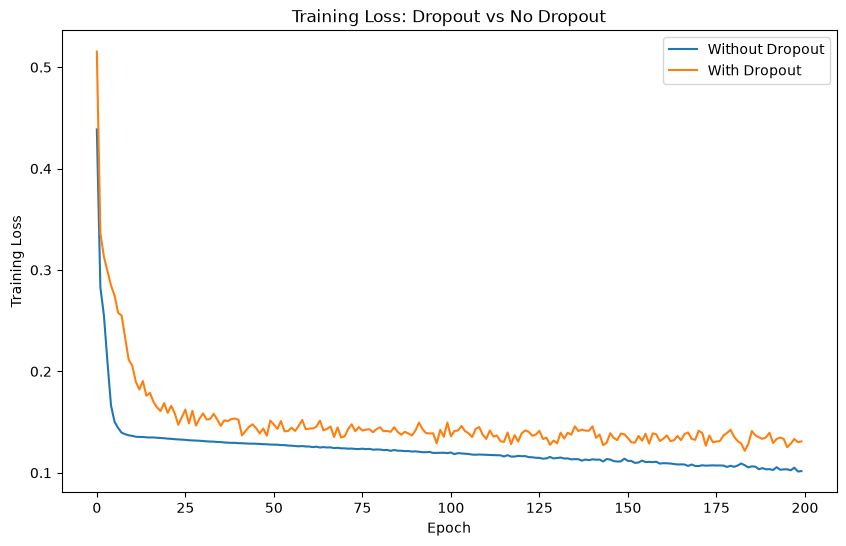

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_no_dropout.history["loss"],
    label="Without Dropout"
)

plt.plot(
    history_dropout.history["loss"],
    label="With Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Dropout vs No Dropout")
plt.legend()

plt.show()

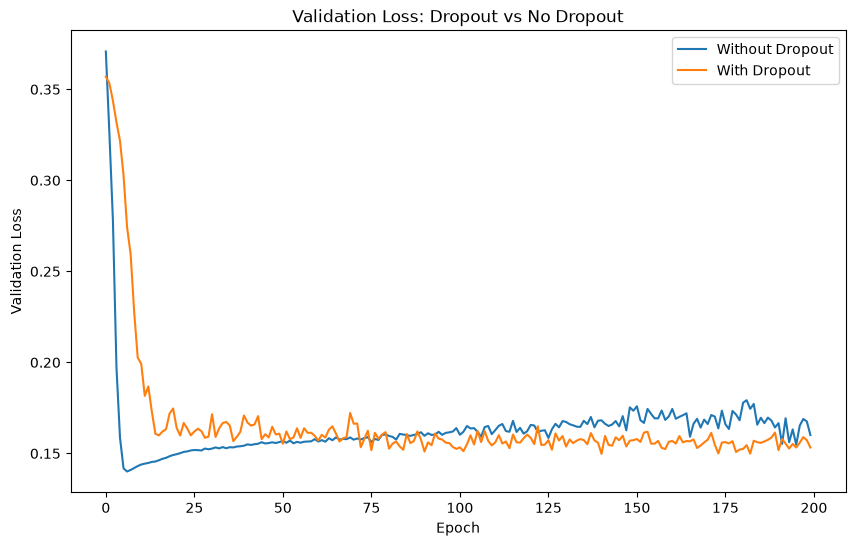

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_no_dropout.history["val_loss"],
    label="Without Dropout"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="With Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Dropout vs No Dropout")
plt.legend()

plt.show()

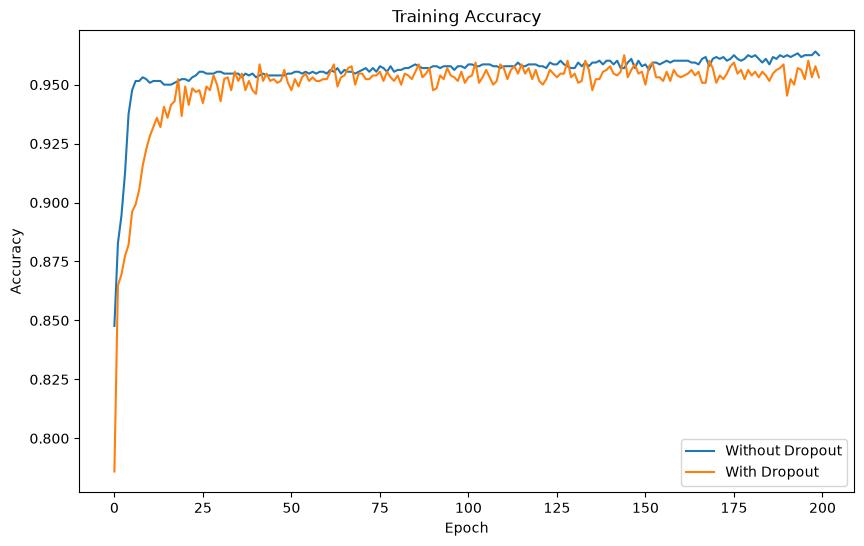

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_no_dropout.history["accuracy"],
    label="Without Dropout"
)

plt.plot(
    history_dropout.history["accuracy"],
    label="With Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()

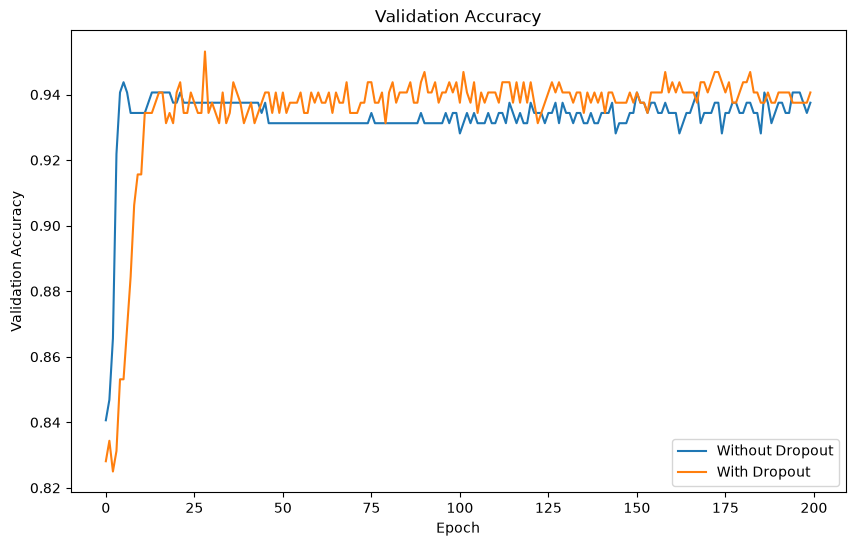

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_no_dropout.history["val_accuracy"],
    label="Without Dropout"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="With Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.show()

In [44]:
results_classification = pd.DataFrame({
    "Model": [
        "Without Dropout",
        "With Dropout"
    ],

    "Test Loss": [
        loss_no_dropout,
        loss_dropout
    ],

    "Test Accuracy": [
        accuracy_no_dropout,
        accuracy_dropout
    ]
})

results_classification

,Model,Test Loss,Test Accuracy
0,Without Dropout,0.220976,0.9225
1,With Dropout,0.185539,0.9250


In [45]:
y_pred_no_dropout = (
    model_no_dropout.predict(X_test, verbose=0) > 0.5
).astype(int).ravel()

y_pred_dropout = (
    model_dropout.predict(X_test, verbose=0) > 0.5
).astype(int).ravel()

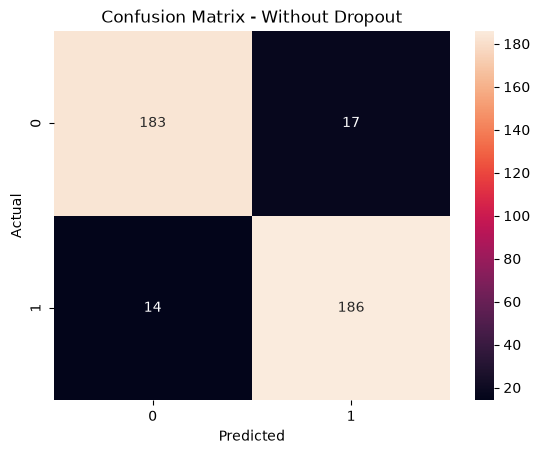

In [46]:
cm_no_dropout = confusion_matrix(
    y_test,
    y_pred_no_dropout
)

sns.heatmap(
    cm_no_dropout,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Without Dropout")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

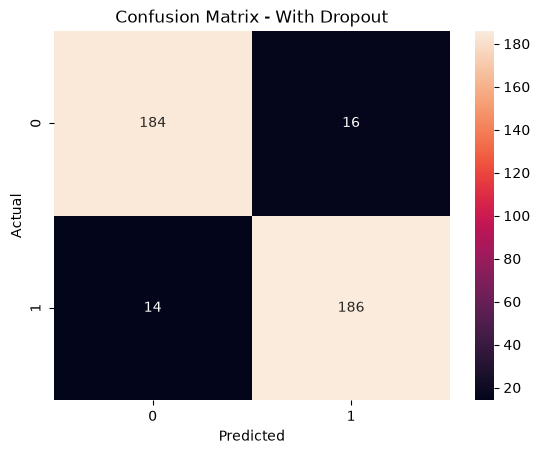

In [47]:
cm_dropout = confusion_matrix(
    y_test,
    y_pred_dropout
)

sns.heatmap(
    cm_dropout,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - With Dropout")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
def plot_decision_boundary(model, X, y, title):

    x1_min = X[:, 0].min() - 0.5
    x1_max = X[:, 0].max() + 0.5

    x2_min = X[:, 1].min() - 0.5
    x2_max = X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    Z = model.predict(
        grid,
        verbose=0
    )

    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="k"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

    plt.show()

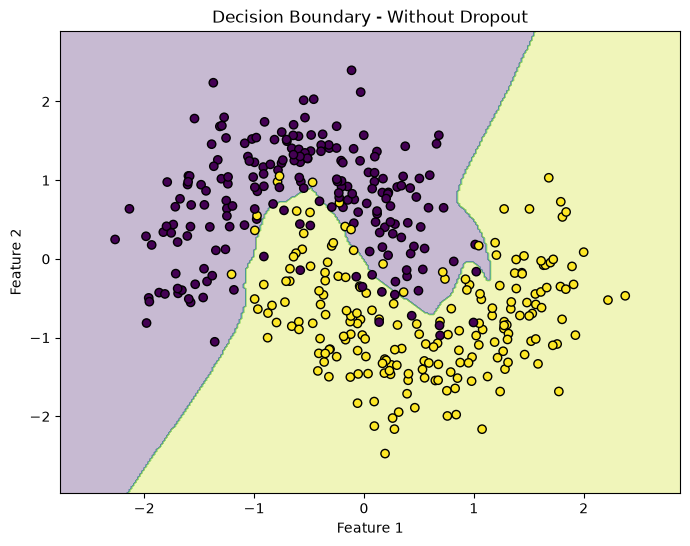

In [49]:
plot_decision_boundary(
    model_no_dropout,
    X_test,
    y_test,
    "Decision Boundary - Without Dropout"
)

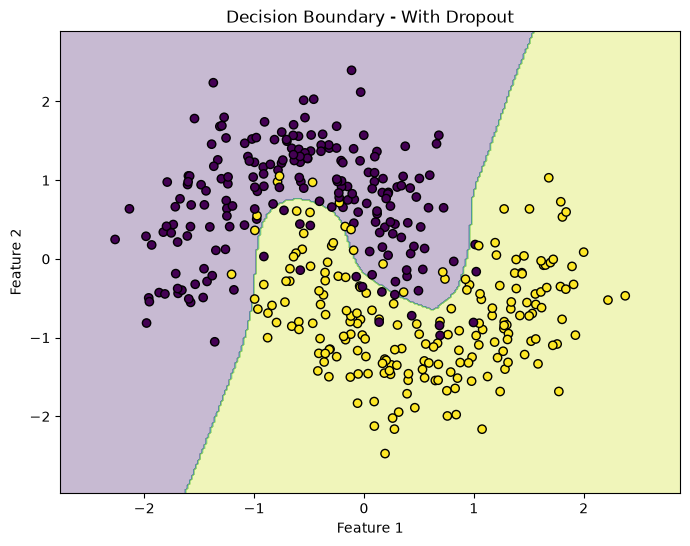

In [50]:
plot_decision_boundary(
    model_dropout,
    X_test,
    y_test,
    "Decision Boundary - With Dropout"
)